In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
# Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [15]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se
from framework import sp_abtest as sb
from framework import sp_modelado as sm

In [11]:
df = sc.leer_csv('../data/processed/02_datos_limpios.csv')
df_e = df.copy()

CSV CARGADO
Archivo: ../data/processed/02_datos_limpios.csv
Filas:   1000
Columnas: 12


#### CARGA DE ARCHIVOS PKL

In [4]:
import joblib

datos = joblib.load('../data/processed/datos_preprocesados.pkl')

X_train_clf = datos['X_train_clf']
X_test_clf = datos['X_test_clf']
y_train_clf = datos['y_train_clf']
y_test_clf = datos['y_test_clf']

#### LogisticRegression

Antes de entrenar, la diferencia clave respecto a la regresión: aquí no predices un número, predices una categoría (0=suspenso, 1=aprobado) — y recuerda el aviso importante que llevamos arrastrando desde el preprocesamiento: aprobado está desbalanceado (90%/10%), así que hay que leer las métricas con más cuidado que en regresión.

##### Paso 1: crear y entrenar el modelo

A diferencia de entrenar_evaluar_regresion(), esta función también te va a imprimir la matriz de confusión y el classification report completo por consola (además de devolverte el diccionario con Accuracy/Precision/Recall/F1) — mucha más información de golpe.

Antes de que lo ejecutes, cómo leer la matriz de confusión cuando la veas

Va a ser una tabla 2x2:

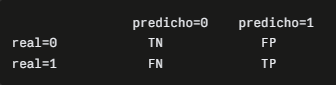

Con solo ~20 casos reales de 0 (suspenso) en el test (recuerda el 10% de 200), presta especial atención a cuántos de esos 20 el modelo consigue identificar bien — es el número que más importa aquí, no el Accuracy global (que con e

In [5]:
from sklearn.linear_model import LogisticRegression

modelo_clf = LogisticRegression()

resultados_clf = sm.entrenar_evaluar_clasificacion(modelo_clf, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(resultados_clf)


Matriz de confusión:
[[  3  17]
 [  2 178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.15      0.24        20
           1       0.91      0.99      0.95       180

    accuracy                           0.91       200
   macro avg       0.76      0.57      0.59       200
weighted avg       0.88      0.91      0.88       200

{'Accuracy': 0.905, 'Precision': 0.8815384615384615, 'Recall': 0.905, 'F1': 0.8784000000000001}


Justo lo que anticipaba con el aviso del desbalanceo — vamos a leerlo con calma, porque el Accuracy de 0,905 esconde un problema real que hay que sacar a la luz.

Empezamos por la matriz de confusión, la parte más honesta del resultado

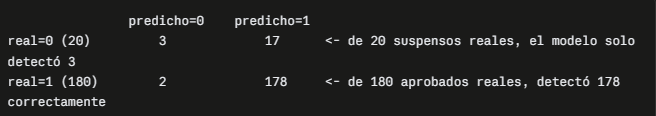

La clase minoritaria (suspenso) está fallando muchísimo

Fíjate en la fila de 0 del classification report:

0 (suspenso):  precision=0.60  recall=0.15  f1=0.24

Recall=0,15 es el número que de verdad importa aquí: de los 20 estudiantes que realmente suspendieron, el modelo solo identificó correctamente a 3 — falló en 17 de 20. El modelo está prediciendo "aprobado" casi siempre, y acierta mucho porque el 90% de los casos reales son "aprobado" — no porque entienda bien qué diferencia a quien suspende.

Por qué el Accuracy (0,905) engaña aquí

Es exactamente el aviso que te di antes de ejecutarlo: un modelo que dijera "todos aprueban" sin mirar ningún dato, ya acertaría el 90% (accuracy=0,90) sin haber aprendido nada. Tu modelo real (0,905) apenas mejora esa base ingenua — la mejora real está solo en esos 3 suspensos que sí detecta.

¿Por qué falla tanto en la clase minoritaria?

Con solo 102 casos de suspenso en todo el dataset (de 1000), y encima repartidos 90/10 en train/test, el modelo tiene muy pocos ejemplos de "cómo es un suspenso" para aprender el patrón — tiende a "refugiarse" en predecir la clase mayoritaria, porque estadísticamente le sale más a cuenta en promedio.

Qué hacer al respecto — no es un fallo tuyo, es un problema conocido con datos desbalanceados

Hay dos vías típicas, que podemos explorar cuando quieras (no hace falta ahora mismo):

1. class_weight='balanced' en LogisticRegression() — le dice al modelo que penalice más los errores en la clase minoritaria, sin tener que tocar los datos.
2. Sobremuestreo/submuestreo (SMOTE, etc.) — técnicas más avanzadas para equilibrar las clases antes de entrenar.

**Modelo de clasificación — LogisticRegression (resultado inicial)**

Accuracy=0.905, pero esta cifra es engañosa dado el desbalanceo
(90%/10%): el modelo solo identifica correctamente 3 de 20 suspensos
reales (recall=0.15 para la clase minoritaria). Predice "aprobado"
de forma casi sistemática, beneficiándose del desbalanceo en el
accuracy sin haber aprendido a distinguir bien el patrón de
suspenso.

Próximo paso: reentrenar con class_weight='balanced' para forzar al
modelo a prestar más atención a la clase minoritaria.

**`class_weight='balanced'` para ver si mejora**

Antes de que lo ejecutes, qué esperar con este cambio: class_weight='balanced' hace que el modelo trate los errores en la clase minoritaria (suspenso) como "más caros" durante el entrenamiento — en la práctica, esto suele significar que el recall de la clase 0 sube (detecta más suspensos reales), pero normalmente a cambio de que la precision de la clase 0 baje (también empieza a marcar como "suspenso" a algunos que en realidad aprobaron) y que el Accuracy global baje un poco (porque ya no se refugia tanto en la clase mayoritaria). Es un trade-off, no una mejora gratis en todo a la vez.

In [6]:
modelo_clf_balanceado = LogisticRegression(class_weight='balanced')

resultados_clf_bal = sm.entrenar_evaluar_clasificacion(modelo_clf_balanceado, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(resultados_clf_bal)


Matriz de confusión:
[[ 13   7]
 [ 53 127]]

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.65      0.30        20
           1       0.95      0.71      0.81       180

    accuracy                           0.70       200
   macro avg       0.57      0.68      0.56       200
weighted avg       0.87      0.70      0.76       200

{'Accuracy': 0.7, 'Precision': 0.8726820443238352, 'Recall': 0.7, 'F1': 0.7582580358465413}


Justo el trade-off que anticipaba, y con mucha intensidad — vamos a leerlo bien, porque aquí hay una decisión de negocio real que tomar, no solo un número "mejor" o "peor".

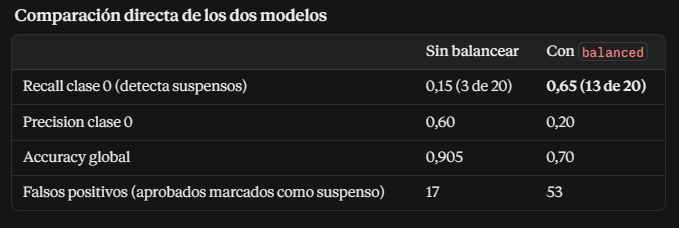

La mejora real, y su coste

Mejora clara: pasas de detectar 3 de 20 suspensos a detectar 13 de 20 — más del cuádruple. Si el objetivo de negocio es "identificar quién necesita ayuda antes de que suspenda", este modelo es muchísimo más útil.

El coste: la precisión de la clase 0 se desploma a 0,20 — de cada 10 estudiantes que el modelo marca como "en riesgo de suspenso", solo 2 realmente lo están; los otros 8 en realidad iban a aprobar. Y el Accuracy global cae del 90,5% al 70%.

¿Cuál es "mejor"? Depende de qué error te sale más caro

Esto no tiene una respuesta puramente estadística — depende del contexto de uso:

Si el modelo se usa para "avisar/apoyar" a estudiantes en riesgo (ej. ofrecerles tutorías extra), el coste de un falso positivo es bajo (le ofreces ayuda a alguien que no la necesitaba, no pasa nada grave) — aquí el modelo balanced es claramente mejor, porque priorizas no dejar a nadie sin detectar.
Si el modelo se usa para decisiones más "duras" (ej. denegar algo, marcar como "en riesgo" de forma pública), un falso positivo tiene coste real — ahí el trade-off es más discutible.

Dado que es un dataset de estudiantes, el caso de uso más natural es el primero (identificar quién necesita apoyo), así que yo me quedaría con el modelo balanced como el más útil, aunque su Accuracy "se vea peor" en el número global.

**Modelo de clasificación — comparación con class_weight='balanced'**

| Métrica | Sin balancear | Balanceado |
|---|---|---|
| Recall suspensos | 0,15 | 0,65 |
| Precision suspensos | 0,60 | 0,20 |
| Accuracy | 0,905 | 0,70 |

Se prioriza el modelo balanceado como resultado final: en un contexto
de identificación temprana de estudiantes en riesgo, el coste de un
falso positivo (ofrecer apoyo a quien no lo necesita) es bajo,
mientras que el de un falso negativo (no detectar a quien va a
suspender) es alto. El Accuracy global, aunque más bajo, es una
métrica engañosa en un dataset desbalanceado (90%/10%) y no refleja
la utilidad real del modelo para este objetivo.

**`comparar_train_test()` para comprobar overfitting en este modelo balanceado**

Un aviso antes de que lo veas: recuerda que comparar_train_test() usa accuracy_score internamente (mira el código de sp_modelado.py) — con este dataset desbalanceado, comparar solo el Accuracy entre train y test puede ser engañoso de la misma forma que ya vimos (un modelo puede tener Accuracy parecido en train y test y aun así fallar mucho en la clase minoritaria en ambos). Así que este resultado te dirá si hay overfitting "grueso" (train muy distinto de test), pero no sustituye a mirar la matriz de confusión de cada lado para una lectura fina — algo a tener en cuenta más que un problema del código en sí.

In [7]:
sm.comparar_train_test(modelo_clf_balanceado, X_train_clf, X_test_clf, y_train_clf, y_test_clf, tipo='clasificacion')

Accuracy Train: 0.7538
Accuracy Test : 0.7000


Diferencia de 0,05 entre train (0,754) y test (0,70) — un poco más de separación que en el modelo de regresión (que tenía solo 0,03), pero sigue siendo una diferencia pequeña, no hay señal de overfitting grave. El modelo generaliza razonablemente bien, coherente con lo que vimos antes.

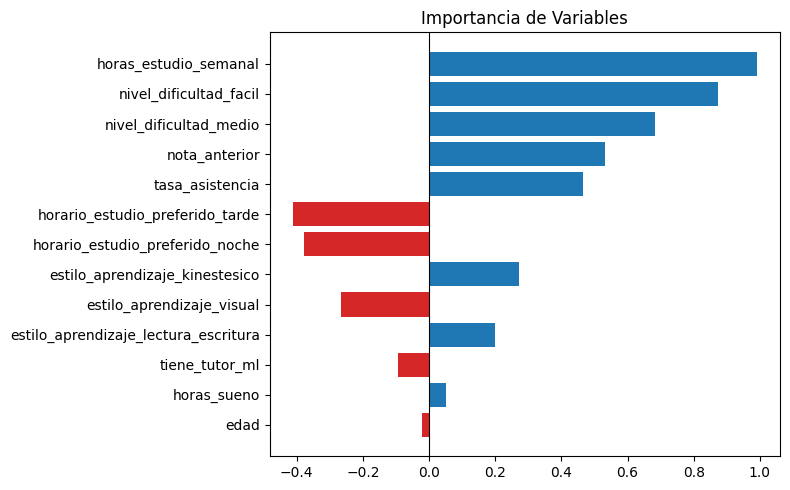

,variable,importancia
0,horas_estudio_semanal,0.990632
6,nivel_dificultad_facil,0.872027
7,nivel_dificultad_medio,0.682128
1,nota_anterior,0.532975
2,tasa_asistencia,0.466185
9,horario_estudio_preferido_tarde,-0.411643
8,horario_estudio_preferido_noche,-0.378088
10,estilo_aprendizaje_kinestesico,0.270879
12,estilo_aprendizaje_visual,-0.266333
11,estilo_aprendizaje_lectura_escritura,0.197850


In [8]:
sm.importancia_variables(modelo_clf_balanceado, X_train_clf.columns)

una diferencia importante a tener en cuenta al interpretarlo (distinta de la regresión lineal): en LogisticRegression, los coeficientes no se leen en "puntos de nota", se leen en escala de log-odds (logaritmo de la razón de probabilidades) — el signo (positivo/negativo) se interpreta igual que antes (aumenta o reduce la probabilidad de aprobar), pero la magnitud exacta no es directamente comparable punto por punto con los coeficientes de la regresión de antes. Lo que sí puedes comparar es el orden relativo de importancia entre variables, que es lo que más nos interesa aquí.

Coincide bastante con la regresión en el top, pero hay dos cambios que merece la pena señalar — uno confirma algo, y otro es una sorpresa real que contradice lo que vimos en el EDA.

✅ Confirma el núcleo duro, mismo orden que en regresión

horas_estudio_semanal  -->  1º<br>
nivel_dificultad_facil  --> 2º<br>
nivel_dificultad_medio  --> (alto también)<br>
nota_anterior           
tasa_asistencia

Las 5 variables más fuertes son las mismas que en el modelo de regresión, en un orden prácticamente idéntico. Buena señal de robustez: no depende de qué objetivo predigas (nota exacta o aprobado/suspenso), las variables importantes son las mismas.

🔴 Sorpresa — horario_estudio_preferido aparece con fuerza aquí, y no la vimos en el EDA

horario_estudio_preferido_tarde -->   -0,41<br>
horario_estudio_preferido_noche  -->  -0,38<br>

Esto es llamativo porque recuerda: en el EDA, horario_estudio_preferido dio p=0,463 contra aprobado (sin relación) y p=0,702 contra nota_final (sin relación) — la descartamos por completo como "sin relación relevante". Y ahora, dentro del modelo, aparece con una magnitud comparable a estilo_aprendizaje (que sí tenía algo de señal en el EDA).

¿Por qué puede pasar esto? No es necesariamente una contradicción — es una diferencia real entre dos formas de mirar los datos:

El chi-cuadrado/ANOVA del EDA mira cada variable aislada, sin las demás.
El coeficiente del modelo mide el efecto de esa variable controlando por todas las demás a la vez — puede revelar relaciones que solo aparecen cuando se ajusta por el resto de variables (a veces llamado "efecto de confusión oculto" o suppressor effect), o puede ser simplemente ruido del modelo con pocas muestras por categoría.
Cómo comprobar cuál de las dos explicaciones es la correcta

Antes de dar por bueno este coeficiente como un hallazgo real, valdría la pena mirar si horario_estudio_preferido está correlacionado con alguna otra variable fuerte del modelo (como hicimos con tiene_tutor/horas_estudio_semanal):

In [12]:
pd.crosstab(df_e['horario_estudio_preferido'], df_e['nivel_dificultad'], normalize='index').round(3)


nivel_dificultad,dificil,facil,medio
horario_estudio_preferido,,,
manana,0.201,0.329,0.470
noche,0.164,0.300,0.536
tarde,0.196,0.320,0.484


In [13]:
df_e.groupby('horario_estudio_preferido')['horas_estudio_semanal'].mean().round(2)

horario_estudio_preferido
manana    10.57
noche      9.86
tarde     10.02
Name: horas_estudio_semanal, dtype: float64

In [14]:
df_e.groupby('horario_estudio_preferido')['nota_anterior'].mean().round(2)

horario_estudio_preferido
manana    69.93
noche     68.60
tarde     71.55
Name: nota_anterior, dtype: float64

Si por ejemplo los estudiantes de noche/tarde tienden a tener más nivel_dificultad_dificil o menos horas de estudio de forma sistemática, eso explicaría por qué el coeficiente "se activa" al controlar por las demás variables, aunque en solitario (EDA univariante) no se viera nada.

**Confirmado — sin apenas peso**

tiene_tutor_ml ->  -0,09<br>
horas_sueno    ->   0,05<br>
edad           ->  -0,02<br>


Coherente con lo visto hasta ahora, aunque llama algo la atención que tiene_tutor_ml salga casi nulo aquí, cuando en regresión tenía 0,68 — otro punto a investigar si te interesa profundizar, aunque no es prioritario.

***`Comprobamos la relación de horario_estudio_preferido con las otras variables para entender el porqué de esta sorpresa`***

No hay ningún patrón claro que explique la sorpresa — ni en nivel_dificultad (los tres horarios se reparten casi igual entre fácil/medio/difícil, diferencias de 1-6 puntos porcentuales) ni en las medias de horas_estudio_semanal, nota_anterior o tasa_asistencia (todas muy parecidas entre los tres horarios, diferencias de menos de 1 punto en la mayoría). No hay ningún efecto de confusión oculto evidente que explique por qué el coeficiente del modelo se dispara.

Conclusión: probablemente sea ruido del modelo, no una relación real

Con esto descartado, la explicación más plausible es la más aburrida: el coeficiente de LogisticRegression para esta variable es inestable, por un motivo muy concreto — recuerda que solo tienes 20 casos de suspenso en todo el test, y probablemente unos 80-90 en el train completo (10% de 800). Cuando divides esos pocos casos entre 3 categorías de horario, cada combinación "horario × suspenso" tiene muy pocas observaciones — con tan poca base, cualquier coeficiente en un modelo lineal puede salir con valores grandes y poco fiables, sin que exista una relación real de fondo. Es una limitación conocida de los modelos lineales con clases minoritarias muy pequeñas.

`horario_estudio_preferido` en el modelo de clasificación — probable artefacto, no hallazgo

El coeficiente del modelo de clasificación asigna una importancia
inesperadamente alta a horario_estudio_preferido (tarde -0,41,
noche -0,38), pese a que el EDA univariante no mostró relación
(p=0,463 con aprobado). Se comprobó si esto se debía a una relación
oculta con nivel_dificultad, horas_estudio_semanal, nota_anterior o
tasa_asistencia — no se encontró ningún patrón que lo explique.

Conclusión: es probable que el coeficiente sea inestable debido al
reducido número de casos de la clase minoritaria (suspenso, ~90 en
train) repartidos entre las 3 categorías de horario. No se recomienda
tratar esto como un hallazgo de negocio real sin validación adicional
(ej. con más datos o un modelo menos sensible a clases pequeñas,
como Random Forest).